# SmartFeed India — nutrition model (CP, fibre, energy)

Inputs: **ingredient name** + optional **moisture %** (sensor) + **form** (ingredient / silage / compounded).

Known feeds still use Indian table **ranges** (not a fake lab decimal). Unknown names use **ExtraTrees + TF-IDF** (leave-one-ingredient-out class acc 79.6%). CP from the name uses **Ridge + TF-IDF** (MAE 5.11 % DM). An MLP was compared and lost; it is not shipped.

Moisture does **not** measure protein. It only converts % DM to as-fed.

Dependencies: `pandas`, `numpy`, `scikit-learn`, `joblib`, `matplotlib`


## 1. Setup


In [10]:
import json
import re
from difflib import get_close_matches
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import MaxAbsScaler, OneHotEncoder
from sklearn.svm import LinearSVC

pd.set_option("display.max_columns", 16)
pd.set_option("display.width", 120)
plt.rcParams.update(
    {
        "figure.figsize": (8.4, 4.2),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.28,
    }
)

here = Path.cwd().resolve()
candidates = [here / "data" / "processed"]
for parent in [here, *here.parents]:
    candidates.append(parent / "data" / "processed")
DATA = next(p for p in candidates if p.exists())
NB_DIR = Path.cwd().resolve()
if not (NB_DIR / "nutrition_estimator.ipynb").exists():
    for parent in [here, *here.parents]:
        hit = parent / "notebooks" / "ml"
        if (hit / "nutrition_estimator.ipynb").exists() or hit.exists():
            NB_DIR = hit
            break
ARTIFACTS = NB_DIR / "artifacts"
ARTIFACTS.mkdir(parents=True, exist_ok=True)

DISCLAIMER = (
    "This model does not measure crude protein from a moisture sensor or a photo. "
    "Known ingredients return the min-max range of Indian tables (NDDB, BIS, ICAR papers). "
    "Unknown names are classified into a feed class, then a class-level estimate is used."
)
TDN_TO_ME = 0.036
print("Processed tables:", DATA)
print("Artifacts:", ARTIFACTS)


Processed tables: /Users/sayangarai/Documents/Programming/Projects/SIH_PS_260111/data/processed
Artifacts: /Users/sayangarai/Documents/Programming/Projects/SIH_PS_260111/notebooks/ml/artifacts


## 2. Name normalisation and aliases


In [11]:
REPLACEMENTS = (
    ("rice bran (de-oiled)", "deoiled rice bran"),
    ("rice bran (deoiled)", "deoiled rice bran"),
    ("cottonseed meal (undecorticated)", "cottonseed cake undecorticated"),
    ("cottonseed meal (decorticated)", "cottonseed meal"),
    ("cottonseed oil cake (undecorticated)", "cottonseed cake undecorticated"),
    ("un-decorticated cottonseed cake", "cottonseed cake undecorticated"),
    ("sunflower meal (undecorticated)", "sunflower meal"),
    ("mustard seed cake", "mustard cake"),
    ("rapeseed oil cake", "mustard cake"),
    ("rape seed cake", "mustard cake"),
    ("rapeseed meal", "mustard meal"),
    ("deoiled mustard cake", "mustard meal"),
    ("groundnut oil cake", "groundnut cake"),
    ("groundnut meal", "groundnut meal"),
    ("soyabean meal", "soybean meal"),
    ("coconut oil cake", "coconut cake"),
    ("sesame oil cake", "til cake"),
    ("til oil cake", "til cake"),
    ("linseed oil cake", "linseed cake"),
    ("wheat bran a", "wheat bran"),
    ("wheat bran b", "wheat bran"),
    ("maize grain", "maize"),
    ("barley grain", "barley"),
    ("oat grain", "oats"),
    ("wheat grain", "wheat"),
    ("broken rice", "rice"),
    ("rice grit", "rice"),
    ("cane molasses", "molasses"),
    ("jowar", "sorghum"),
    ("cotton seed cake", "cottonseed cake"),
    ("dorb", "deoiled rice bran"),
    ("gnc", "groundnut cake"),
    ("sarson khali", "mustard cake"),
    ("sarson cake", "mustard cake"),
    ("binola khali", "cottonseed cake undecorticated"),
    ("wheat chokar", "wheat bran"),
    ("chokar", "wheat bran"),
    ("gram flour", "gram"),
    ("tuar chuni", "arhar chuni"),
)
FARMER_ALIASES = {
    "maize silage": "maize silage",
    "corn silage": "maize silage",
    "wheat silage": "wheat silage",
    "compounded cattle feed": "compounded feed",
    "cattle feed": "compounded feed",
    "oat": "oats",
}
CLASS_KEYWORDS = (
    ("silage", "silage"),
    ("straw", "crop_residue"),
    ("stover", "crop_residue"),
    ("bhusa", "crop_residue"),
    ("hay", "hay"),
    ("molasses", "molasses"),
    ("compounded", "compounded"),
    ("chuni", "byproducts"),
    ("bran", "byproducts"),
    ("polish", "byproducts"),
    ("husk", "byproducts"),
    ("hull", "byproducts"),
    ("meal", "oilcakes"),
    ("cake", "oilcakes"),
    ("khali", "oilcakes"),
)
CLASS_MAP = {
    "grains": "grains",
    "grain": "grains",
    "energy": "grains",
    "milling_byproducts": "byproducts",
    "byproducts": "byproducts",
    "protein": "oilcakes",
    "oilcakes": "oilcakes",
    "hay": "hay",
    "crop_residue": "crop_residue",
    "molasses": "molasses",
    "waste": "waste",
    "other": "other",
    "silage": "silage",
    "compounded": "compounded",
}


def normalize_name(name: str) -> str:
    text = str(name).strip().lower()
    text = text.replace("de-oiled", "deoiled").replace("soyabean", "soybean")
    text = re.sub(r"[()]", " ", text)
    text = text.replace("-", " ")
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = text.replace("de oiled", "deoiled")
    if text in FARMER_ALIASES:
        return FARMER_ALIASES[text]
    for src, dst in REPLACEMENTS:
        if text == src or text.startswith(src + " "):
            return (dst + text[len(src) :]).strip()
    return text


def class_from_name(canonical: str, fallback: str | None = None) -> str:
    for needle, label in CLASS_KEYWORDS:
        if needle in canonical:
            return label
    return fallback or "other"


def _num(value):
    if value is None:
        return None
    try:
        if pd.isna(value):
            return None
    except TypeError:
        pass
    return float(value)


print("sarson khali ->", normalize_name("sarson khali"))
print("DORB ->", normalize_name("DORB"))
print("oats ->", normalize_name("oats"))


sarson khali -> mustard cake
DORB -> deoiled rice bran
oats -> oats


## 3. Build the unified Indian training table


In [12]:
def make_row(raw_name, feed_class, source, cp, cf=None, ndf=None, ee=None, me=None, moisture=None, form="ingredient"):
    canonical = normalize_name(raw_name)
    mapped = CLASS_MAP.get(feed_class, feed_class)
    if mapped in {"grains", "energy"} and class_from_name(canonical) != "other":
        mapped = class_from_name(canonical, mapped)
    return {
        "raw_name": raw_name,
        "canonical": canonical,
        "feed_class": mapped,
        "form": form,
        "source": source,
        "cp_pct_dm": cp,
        "cf_pct_dm": cf,
        "ndf_pct_dm": ndf,
        "ee_pct_dm": ee,
        "me_mcal_kg": me,
        "moisture_pct": moisture,
    }


rows = []
nddb = pd.read_csv(DATA / "nddb_2012_concentrate_composition.csv")
for r in nddb.itertuples(index=False):
    rows.append(make_row(r.ingredient, r.group, "nddb_2012_concentrate", _num(r.cp_pct_dm), _num(r.cf_pct_dm), _num(r.ndf_pct_dm), _num(r.ee_pct_dm), _num(r.me_mcal_kg)))

hay = pd.read_csv(DATA / "nddb_2012_roughage_composition.csv")
for r in hay.itertuples(index=False):
    rows.append(make_row(r.ingredient, "hay", "nddb_2012_roughage", _num(r.cp_pct_dm), _num(r.cf_pct_dm), _num(r.ndf_pct_dm), _num(r.ee_pct_dm), _num(r.me_mcal_kg), form="forage"))

annex = pd.read_csv(DATA / "bis_is2052_2009_annex_c_ingredient_typical_composition.csv")
for r in annex.itertuples(index=False):
    rows.append(make_row(r.ingredient, r.category, "bis_annex_c", _num(r.cp_pct), _num(r.cf_pct), None, _num(r.ee_pct), None, _num(r.moisture_pct)))

dey = pd.read_csv(DATA / "dey_2014_bihar_feed_composition.csv")
for r in dey.itertuples(index=False):
    moisture = None if pd.isna(r.dm_pct) else 100.0 - float(r.dm_pct)
    form = "forage" if r.category in {"crop_residue", "other"} else "ingredient"
    rows.append(make_row(r.feed, r.category, "dey_2014_bihar", _num(r.cp_pct_dm), _num(r.cf_pct_dm), None, _num(r.ee_pct_dm), None, moisture, form))

kannan = pd.read_csv(DATA / "kannan_2017_nw_himalayan_concentrates.csv")
for rec in kannan.to_dict(orient="records"):
    fc = "oilcakes" if rec["class"] == "Protein" else "grains"
    rows.append(make_row(rec["feed"], fc, "kannan_2017", _num(rec["cp_pct_dm"]), None, _num(rec["ndf_pct_dm"]), _num(rec["ee_pct_dm"])))

singh = pd.read_csv(DATA / "singh_2016_indian_energy_protein_feeds.csv")
for rec in singh.to_dict(orient="records"):
    fc = "oilcakes" if rec["class"] == "Protein" else "grains"
    rows.append(make_row(
        rec["feed"], fc, "singh_2016",
        None if pd.isna(rec["cp_g_kg_dm"]) else rec["cp_g_kg_dm"] / 10.0,
        None, None if pd.isna(rec["ndf_g_kg_dm"]) else rec["ndf_g_kg_dm"] / 10.0,
        None if pd.isna(rec["ee_g_kg_dm"]) else rec["ee_g_kg_dm"] / 10.0,
    ))

hundal = pd.read_csv(DATA / "hundal_2020_wheat_silage.csv")
for r in hundal.itertuples(index=False):
    me = None if pd.isna(r.tdn_pct) else float(r.tdn_pct) * TDN_TO_ME
    rows.append(make_row("wheat silage", "silage", "hundal_2020", _num(r.cp_pct_dm), None, _num(r.ndf_pct_dm), _num(r.ee_pct_dm), me, form="silage"))

brar = pd.read_csv(DATA / "brar_2021_punjab_maize_cultivar_silage.csv")
for r in brar.itertuples(index=False):
    moisture = None if pd.isna(r.dm_pct) else 100.0 - float(r.dm_pct)
    me = None if pd.isna(r.tdn_pct) else float(r.tdn_pct) * TDN_TO_ME
    rows.append(make_row("maize silage", "silage", "brar_2021", _num(r.cp_pct_dm), None, _num(r.ndf_pct_dm), _num(r.ee_pct_dm), me, moisture, form="silage"))

train = pd.DataFrame(rows)
train["fibre_pct_dm"] = train["cf_pct_dm"].where(train["cf_pct_dm"].notna(), train["ndf_pct_dm"])
print(train.shape, "rows;", train.canonical.nunique(), "canonical ingredients")
display(train.groupby("feed_class")["cp_pct_dm"].agg(["count", "mean", "min", "max"]).round(2))
display(train.head())


(133, 12) rows; 77 canonical ingredients


,count,mean,min,max
feed_class,,,,
byproducts,26,15.51,4.50,46.00
crop_residue,10,6.72,2.94,13.05
grains,28,12.25,8.00,29.00
hay,10,8.80,3.50,16.00
molasses,1,2.00,2.00,2.00
oilcakes,38,33.57,3.00,53.00
other,2,6.75,5.04,8.46
silage,11,7.97,5.55,9.70
waste,7,15.00,6.00,26.00


,raw_name,canonical,feed_class,form,source,cp_pct_dm,cf_pct_dm,ndf_pct_dm,ee_pct_dm,me_mcal_kg,moisture_pct,fibre_pct_dm
0,Maize,maize,grains,ingredient,nddb_2012_concentrate,9.0,2.0,15.6,4.2,3.1,NaN,2.0
1,Sorghum,sorghum,grains,ingredient,nddb_2012_concentrate,8.7,3.0,10.9,2.5,3.0,NaN,3.0
2,Wheat,wheat,grains,ingredient,nddb_2012_concentrate,11.0,2.0,16.0,2.6,2.9,NaN,2.0
3,Barley,barley,grains,ingredient,nddb_2012_concentrate,12.0,5.9,20.0,2.5,2.8,NaN,5.9
4,Oats,oats,grains,ingredient,nddb_2012_concentrate,11.0,15.5,13.8,4.4,2.6,NaN,15.5


## 4. Crude protein by feed class


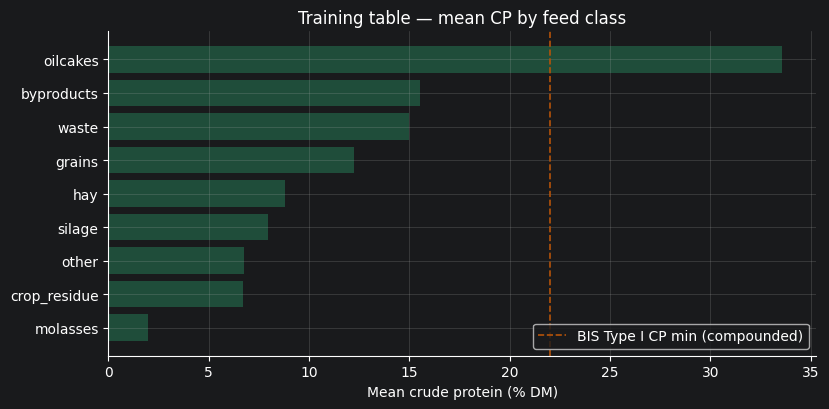

In [13]:
cp_by_class = train.groupby("feed_class")["cp_pct_dm"].mean().sort_values()
fig, ax = plt.subplots()
ax.barh(cp_by_class.index.astype(str), cp_by_class.values, color="#1f4d3a")
ax.axvline(22, color="#b45309", linestyle="--", linewidth=1.2, label="BIS Type I CP min (compounded)")
ax.set_xlabel("Mean crude protein (% DM)")
ax.set_title("Training table — mean CP by feed class")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 5. Ingredient lookup (min / max across Indian sources)


In [14]:
metrics = ["cp_pct_dm", "cf_pct_dm", "ndf_pct_dm", "fibre_pct_dm", "ee_pct_dm", "me_mcal_kg", "moisture_pct"]
parts = []
for (canonical, feed_class, form), g in train.groupby(["canonical", "feed_class", "form"], dropna=False):
    rec = {
        "canonical": canonical,
        "feed_class": feed_class,
        "form": form,
        "n_rows": len(g),
        "n_sources": g["source"].nunique(),
        "sources": ";".join(sorted(g["source"].unique())),
    }
    for col in metrics:
        s = g[col].dropna()
        rec[f"{col}_mean"] = float(s.mean()) if len(s) else None
        rec[f"{col}_min"] = float(s.min()) if len(s) else None
        rec[f"{col}_max"] = float(s.max()) if len(s) else None
    parts.append(rec)
lookup = pd.DataFrame(parts).sort_values(["feed_class", "canonical"]).reset_index(drop=True)
print("Lookup ingredients:", len(lookup))
display(lookup.loc[lookup.canonical.isin(["mustard cake", "wheat bran", "maize", "maize silage", "soybean meal"])])


Lookup ingredients: 77


,canonical,feed_class,form,n_rows,n_sources,sources,cp_pct_dm_mean,cp_pct_dm_min,...,ee_pct_dm_min,ee_pct_dm_max,me_mcal_kg_mean,me_mcal_kg_min,me_mcal_kg_max,moisture_pct_mean,moisture_pct_min,moisture_pct_max
13,wheat bran,byproducts,ingredient,6,5,bis_annex_c;dey_2014_bihar;kannan_2017;nddb_20...,14.926667,13.20,...,2.20,4.00,2.70000,2.70000,2.70000,9.025,8.00,10.05
29,maize,grains,ingredient,5,5,bis_annex_c;dey_2014_bihar;kannan_2017;nddb_20...,9.394000,9.00,...,1.75,4.77,3.10000,3.10000,3.10000,10.800,10.00,11.60
57,mustard cake,oilcakes,ingredient,5,5,bis_annex_c;dey_2014_bihar;kannan_2017;nddb_20...,34.940000,30.80,...,7.50,8.33,2.90000,2.90000,2.90000,9.560,9.00,10.12
61,soybean meal,oilcakes,ingredient,3,3,bis_annex_c;kannan_2017;nddb_2012_concentrate,47.743333,45.00,...,1.12,1.40,2.50000,2.50000,2.50000,10.000,10.00,10.00
68,maize silage,silage,silage,3,1,brar_2021,7.380000,5.55,...,1.77,2.07,2.25012,2.23236,2.26152,78.700,77.53,80.47


## 6. Model comparison (ExtraTrees / Ridge won)

Leave-one-ingredient-out so we do not score by memorising the same name. Keyword tags (`cake`, `bran`, `straw`, …) are prepended to the text.

- **Class:** ExtraTrees vs logistic vs LinearSVC vs MLP. Winner: ExtraTrees.
- **CP from name:** class-mean vs Ridge vs ExtraTrees vs MLP (96–48–24). Winner: Ridge.
- Winners are fitted on all rows and used only when lookup misses. MLP is not shipped.


In [15]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

KEYWORD_TAGS = (
    "silage", "straw", "stover", "bhusa", "hay", "molasses",
    "chuni", "bran", "polish", "husk", "hull", "meal", "cake", "khali", "grain",
)


def enrich(text: str) -> str:
    s = str(text).strip().lower()
    tags = [k for k in KEYWORD_TAGS if k in s]
    return (" ".join(tags) + " " + s).strip()


def text_features():
    return FeatureUnion(
        [
            ("char", TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 6), min_df=1)),
            ("word", TfidfVectorizer(analyzer="word", ngram_range=(1, 2), min_df=1)),
        ]
    )


def name_frame(frame: pd.DataFrame) -> pd.DataFrame:
    a = frame[["raw_name", "canonical", "feed_class"]].copy()
    b = frame[["canonical", "feed_class"]].copy()
    b["raw_name"] = b["canonical"]
    names = pd.concat([a, b], ignore_index=True)
    names["raw_name"] = names["raw_name"].astype(str).str.strip().str.lower()
    names = names.drop_duplicates("raw_name")
    keep = names["feed_class"].value_counts()
    names = names[names["feed_class"].isin(keep[keep >= 2].index)].reset_index(drop=True)
    names["text"] = names["raw_name"].map(enrich)
    return names


def regression_frame(frame: pd.DataFrame, target: str) -> pd.DataFrame:
    work = frame.dropna(subset=[target]).copy()
    raw = work[["raw_name", "canonical", target, "feed_class"]].copy()
    raw["text"] = raw["raw_name"].astype(str).str.lower()
    raw = raw.rename(columns={target: "y"})
    canon = work.groupby("canonical", as_index=False).agg(y=(target, "mean"), feed_class=("feed_class", "first"))
    canon["text"] = canon["canonical"]
    out = pd.concat([raw[["text", "canonical", "y", "feed_class"]], canon[["text", "canonical", "y", "feed_class"]]], ignore_index=True)
    out["text"] = out["text"].astype(str).str.strip().str.lower().map(enrich)
    return out.drop_duplicates("text").reset_index(drop=True)


def logo_classify(pipe, X, y, groups):
    preds = np.empty(len(X), dtype=object)
    for tr, te in LeaveOneGroupOut().split(X, y, groups):
        model = clone(pipe)
        model.fit(X.iloc[tr], y.iloc[tr])
        preds[te] = model.predict(X.iloc[te])
    return float(accuracy_score(y, preds)), float(f1_score(y, preds, average="macro", zero_division=0))


def logo_mae(pipe, X, y, groups, class_labels=None):
    preds = np.full(len(X), np.nan)
    for tr, te in LeaveOneGroupOut().split(X, y, groups):
        if pipe is None:
            means = pd.Series(y[tr], index=X.iloc[tr].index).groupby(class_labels.iloc[tr]).mean() if False else None
            # class-mean baseline
            tmp = pd.DataFrame({"y": y[tr], "c": class_labels.iloc[tr]})
            means = tmp.groupby("c")["y"].mean()
            glob = float(np.mean(y[tr]))
            preds[te] = class_labels.iloc[te].map(means).fillna(glob).to_numpy()
        else:
            model = clone(pipe)
            model.fit(X.iloc[tr], y[tr])
            preds[te] = model.predict(X.iloc[te])
    return float(mean_absolute_error(y, preds))


names = name_frame(train)
X_name, y_name, g_name = names["text"], names["feed_class"], names["canonical"].to_numpy()

clf_candidates = {
    "LogReg + TF-IDF": Pipeline([("tfidf", text_features()), ("clf", LogisticRegression(max_iter=800, C=4.0, class_weight="balanced"))]),
    "LinearSVC + TF-IDF": Pipeline([("tfidf", text_features()), ("clf", LinearSVC(C=1.0, class_weight="balanced"))]),
    "ExtraTrees + TF-IDF": Pipeline(
        [("tfidf", text_features()), ("clf", ExtraTreesClassifier(n_estimators=200, random_state=42, class_weight="balanced"))]
    ),
    "ANN MLP(64,32) + TF-IDF": Pipeline(
        [
            ("tfidf", text_features()),
            ("scale", MaxAbsScaler()),
            ("clf", MLPClassifier(hidden_layer_sizes=(64, 32), activation="relu", alpha=1e-3, max_iter=800, random_state=42)),
        ]
    ),
}

clf_rows = []
best_clf_name, best_clf_acc, name_clf = None, -1.0, None
print("Name -> feed class  (leave-one-ingredient-out)")
for label, pipe in clf_candidates.items():
    acc, f1 = logo_classify(pipe, X_name, y_name, g_name)
    clf_rows.append({"model": label, "cv_accuracy": round(acc, 3), "macro_F1": round(f1, 3)})
    print(f"  {label:28s}  acc={acc:.3f}  F1={f1:.3f}")
    if acc > best_clf_acc:
        best_clf_name, best_clf_acc, name_clf = label, acc, clone(pipe)

name_clf.fit(X_name, y_name)
name_acc = round(best_clf_acc, 3)
display(pd.DataFrame(clf_rows).sort_values("cv_accuracy", ascending=False))
print("Winner (class):", best_clf_name)

cp_df = regression_frame(train, "cp_pct_dm")
X_cp, y_cp, g_cp = cp_df["text"], cp_df["y"].to_numpy(), cp_df["canonical"].to_numpy()

reg_candidates = {
    "Ridge + TF-IDF": Pipeline([("tfidf", text_features()), ("reg", Ridge(alpha=0.5))]),
    "ANN MLP(96,48,24) + TF-IDF": Pipeline(
        [
            ("tfidf", text_features()),
            ("scale", MaxAbsScaler()),
            (
                "reg",
                MLPRegressor(
                    hidden_layer_sizes=(96, 48, 24),
                    activation="relu",
                    alpha=5e-4,
                    max_iter=1200,
                    random_state=0,
                    learning_rate_init=0.002,
                ),
            ),
        ]
    ),
}

print("\nCrude protein from name  (leave-one-ingredient-out)")
class_mae = logo_mae(None, X_cp, y_cp, g_cp, class_labels=cp_df["feed_class"])
print(f"  {'Class-mean baseline':28s}  MAE={class_mae:.3f} % DM")
reg_rows = [{"model": "Class-mean baseline", "cv_mae_cp": round(class_mae, 3)}]
best_reg_name, best_reg_mae, cp_model = "Class-mean baseline", class_mae, None
for label, pipe in reg_candidates.items():
    mae = logo_mae(pipe, X_cp, y_cp, g_cp)
    reg_rows.append({"model": label, "cv_mae_cp": round(mae, 3)})
    print(f"  {label:28s}  MAE={mae:.3f} % DM")
    if mae < best_reg_mae:
        best_reg_name, best_reg_mae, cp_model = label, mae, clone(pipe)

if cp_model is None:
    raise RuntimeError("Name model failed to beat class mean.")
cp_model.fit(X_cp, y_cp)

nutrient_models = {"cp_pct_dm": cp_model}
nutrient_metrics = [{"target": "cp_pct_dm", "n": int(len(cp_df)), "cv": "leave_one_ingredient_out", "winner": best_reg_name, "mae": round(best_reg_mae, 3)}]
for target in ["fibre_pct_dm", "ee_pct_dm", "me_mcal_kg"]:
    rdf = regression_frame(train, target)
    model = clone(cp_model)
    model.fit(rdf["text"], rdf["y"].to_numpy())
    nutrient_models[target] = model
    nutrient_metrics.append({"target": target, "n": int(len(rdf)), "cv": "fitted_same_architecture_as_cp_winner", "winner": best_reg_name})

display(pd.DataFrame(reg_rows).sort_values("cv_mae_cp"))
print("Winner (CP):", best_reg_name, "MAE", round(best_reg_mae, 3))
print("Winners: ExtraTrees (class), Ridge (CP). MLP lost on this split and is not shipped.")


Name -> feed class  (leave-one-ingredient-out)
  LogReg + TF-IDF               acc=0.787  F1=0.599
  LinearSVC + TF-IDF            acc=0.787  F1=0.576
  ExtraTrees + TF-IDF           acc=0.796  F1=0.582
  ANN MLP(64,32) + TF-IDF       acc=0.722  F1=0.528


,model,cv_accuracy,macro_F1
2,ExtraTrees + TF-IDF,0.796,0.582
0,LogReg + TF-IDF,0.787,0.599
1,LinearSVC + TF-IDF,0.787,0.576
3,"ANN MLP(64,32) + TF-IDF",0.722,0.528


Winner (class): ExtraTrees + TF-IDF

Crude protein from name  (leave-one-ingredient-out)
  Class-mean baseline           MAE=6.154 % DM
  Ridge + TF-IDF                MAE=5.111 % DM
  ANN MLP(96,48,24) + TF-IDF    MAE=5.523 % DM


,model,cv_mae_cp
1,Ridge + TF-IDF,5.111
2,"ANN MLP(96,48,24) + TF-IDF",5.523
0,Class-mean baseline,6.154


Winner (CP): Ridge + TF-IDF MAE 5.111
Winners: ExtraTrees (class), Ridge (CP). MLP lost on this split and is not shipped.


## 7. Predict: lookup first, then the winning name model


In [16]:
limits = pd.read_csv(DATA / "bis_is2052_2023_compounded_feed_limits.csv")
BIS = {str(r.characteristic): {"type_I": r.type_I, "type_II": r.type_II} for r in limits.itertuples(index=False)}
CANONICAL = lookup["canonical"].tolist()


def as_fed(value, moisture_pct):
    if value is None or moisture_pct is None:
        return None
    return round(float(value) * (1.0 - float(moisture_pct) / 100.0), 2)


def span(row, stem):
    mean = row.get(f"{stem}_mean")
    if mean is None or (isinstance(mean, float) and pd.isna(mean)):
        return None
    lo, hi = row.get(f"{stem}_min"), row.get(f"{stem}_max")
    return {"mean": round(float(mean), 2), "min": round(float(lo), 2), "max": round(float(hi), 2)}


def as_fed_span(s, moisture_pct):
    if not s or moisture_pct is None:
        return None
    return {"mean": as_fed(s["mean"], moisture_pct), "min": as_fed(s["min"], moisture_pct), "max": as_fed(s["max"], moisture_pct)}


def name_span(target, text):
    pred = float(nutrient_models[target].predict([enrich(text)])[0])
    band = float(best_reg_mae) if target == "cp_pct_dm" else max(1.5, abs(pred) * 0.25)
    return {
        "mean": round(pred, 2),
        "min": round(pred - band, 2),
        "max": round(pred + band, 2),
        "note": f"{best_reg_name} on the typed name; not a lab value",
    }


def predict(ingredient: str, moisture_pct=None, form=None) -> dict:
    canonical = normalize_name(ingredient)
    if form == "silage" and "silage" not in canonical:
        canonical = f"{canonical} silage"
    if form == "compounded":
        return {
            "ingredient": ingredient,
            "method": "bis_standard_only",
            "canonical": canonical,
            "bis_compounded_feed": {
                "type_I_cp_min": float(BIS["Crude protein"]["type_I"]),
                "type_II_cp_min": float(BIS["Crude protein"]["type_II"]),
                "moisture_max": float(BIS["Moisture"]["type_I"]),
                "note": "Finished cattle feed CP depends on the mill formula. Look up each ingredient.",
            },
            "disclaimer": DISCLAIMER,
        }

    hit = lookup[lookup.canonical == canonical]
    match = "exact"
    if hit.empty:
        close = get_close_matches(canonical, CANONICAL, n=1, cutoff=0.82)
        if close:
            hit = lookup[lookup.canonical == close[0]]
            match = f"fuzzy:{close[0]}"
            canonical = close[0]

    if not hit.empty:
        row = hit.iloc[0].to_dict()
        if moisture_pct is None and pd.notna(row.get("moisture_pct_mean")):
            moisture_pct = float(row["moisture_pct_mean"])
        nutrients = {
            "crude_protein_pct_dm": span(row, "cp_pct_dm"),
            "fibre_pct_dm": span(row, "fibre_pct_dm"),
            "crude_fibre_pct_dm": span(row, "cf_pct_dm"),
            "ndf_pct_dm": span(row, "ndf_pct_dm"),
            "fat_ee_pct_dm": span(row, "ee_pct_dm"),
            "energy_me_mcal_kg": span(row, "me_mcal_kg"),
        }
        method, feed_class, sources, n_rows = "indian_table_lookup", row["feed_class"], row.get("sources"), int(row["n_rows"])
    else:
        feed_class = str(name_clf.predict([enrich(canonical)])[0])
        method, match, sources, n_rows = "best_cv_name_model", best_clf_name, None, None
        nutrients = {
            "crude_protein_pct_dm": name_span("cp_pct_dm", canonical),
            "fibre_pct_dm": name_span("fibre_pct_dm", canonical),
            "crude_fibre_pct_dm": None,
            "ndf_pct_dm": None,
            "fat_ee_pct_dm": name_span("ee_pct_dm", canonical),
            "energy_me_mcal_kg": name_span("me_mcal_kg", canonical),
        }

    return {
        "ingredient": ingredient,
        "canonical": canonical,
        "moisture_pct": moisture_pct,
        "form": form,
        "method": method,
        "match": match,
        "feed_class": feed_class,
        "nutrients_pct_dm": nutrients,
        "nutrients_as_fed": {
            "crude_protein_pct": as_fed_span(nutrients["crude_protein_pct_dm"], moisture_pct),
            "fibre_pct": as_fed_span(nutrients["fibre_pct_dm"], moisture_pct),
        },
        "sources": sources,
        "n_source_rows": n_rows,
        "disclaimer": DISCLAIMER,
    }


print("Functions ready.")


Functions ready.


## 8. Demo predictions


In [17]:
demos = [
    predict("mustard cake", moisture_pct=10),
    predict("sarson khali", moisture_pct=11),
    predict("wheat bran", moisture_pct=12),
    predict("maize", moisture_pct=70, form="silage"),
    predict("unknown green cake"),
    predict("cattle feed", form="compounded"),
]
for item in demos:
    cp = (item.get("nutrients_pct_dm") or {}).get("crude_protein_pct_dm")
    print("=" * 60)
    print(item["ingredient"], "|", item["method"], "| class:", item.get("feed_class"))
    if cp:
        print("  CP % DM:", cp)
        print("  CP as-fed:", item["nutrients_as_fed"]["crude_protein_pct"])
    if item.get("bis_compounded_feed"):
        print(" ", item["bis_compounded_feed"])


mustard cake | indian_table_lookup | class: oilcakes
  CP % DM: {'mean': 34.94, 'min': 30.8, 'max': 38.0}
  CP as-fed: {'mean': 31.45, 'min': 27.72, 'max': 34.2}
sarson khali | indian_table_lookup | class: oilcakes
  CP % DM: {'mean': 34.94, 'min': 30.8, 'max': 38.0}
  CP as-fed: {'mean': 31.1, 'min': 27.41, 'max': 33.82}
wheat bran | indian_table_lookup | class: byproducts
  CP % DM: {'mean': 14.93, 'min': 13.2, 'max': 16.0}
  CP as-fed: {'mean': 13.14, 'min': 11.62, 'max': 14.08}
maize | indian_table_lookup | class: silage
  CP % DM: {'mean': 7.38, 'min': 5.55, 'max': 8.44}
  CP as-fed: {'mean': 2.21, 'min': 1.67, 'max': 2.53}
unknown green cake | best_cv_name_model | class: oilcakes
  CP % DM: {'mean': 33.76, 'min': 28.65, 'max': 38.87, 'note': 'Ridge + TF-IDF on the typed name; not a lab value'}
  CP as-fed: None
cattle feed | bis_standard_only | class: None
  {'type_I_cp_min': 22.0, 'type_II_cp_min': 20.0, 'moisture_max': 11.0, 'note': 'Finished cattle feed CP depends on the mill 

## 9. Save artifacts


In [18]:
bundle = {
    "disclaimer": DISCLAIMER,
    "lookup": lookup.to_dict(orient="records"),
    "name_classifier": name_clf,
    "nutrient_models": nutrient_models,
    "canonical_names": CANONICAL,
    "bis_limits": BIS,
    "best_classifier": best_clf_name,
    "best_regressor": best_reg_name,
    "cv_classifier_accuracy": name_acc,
    "cv_cp_mae": round(best_reg_mae, 3),
}
model_path = ARTIFACTS / "nutrition_estimator.joblib"
joblib.dump(bundle, model_path)
train.to_csv(ARTIFACTS / "training_rows.csv", index=False)
lookup.to_csv(ARTIFACTS / "ingredient_lookup.csv", index=False)
report = {
    "disclaimer": DISCLAIMER,
    "n_training_rows": int(len(train)),
    "n_canonical_ingredients": int(lookup.canonical.nunique()),
    "name_classifier_cv_accuracy": name_acc,
    "name_classifier_winner": best_clf_name,
    "cp_model_winner": best_reg_name,
    "cp_cv_mae": round(best_reg_mae, 3),
    "nutrient_models": nutrient_metrics,
    "artifact": str(model_path.relative_to(DATA.parents[1])),
}
(ARTIFACTS / "metrics.json").write_text(json.dumps(report, indent=2), encoding="utf-8")
print(json.dumps(report, indent=2)[:1500])
print("Saved", model_path)


{
  "disclaimer": "This model does not measure crude protein from a moisture sensor or a photo. Known ingredients return the min-max range of Indian tables (NDDB, BIS, ICAR papers). Unknown names are classified into a feed class, then a class-level estimate is used.",
  "n_training_rows": 133,
  "n_canonical_ingredients": 77,
  "name_classifier_cv_accuracy": 0.796,
  "name_classifier_winner": "ExtraTrees + TF-IDF",
  "cp_model_winner": "Ridge + TF-IDF",
  "cp_cv_mae": 5.111,
  "nutrient_models": [
    {
      "target": "cp_pct_dm",
      "n": 108,
      "cv": "leave_one_ingredient_out",
      "winner": "Ridge + TF-IDF",
      "mae": 5.111
    },
    {
      "target": "fibre_pct_dm",
      "n": 106,
      "cv": "fitted_same_architecture_as_cp_winner",
      "winner": "Ridge + TF-IDF"
    },
    {
      "target": "ee_pct_dm",
      "n": 104,
      "cv": "fitted_same_architecture_as_cp_winner",
      "winner": "Ridge + TF-IDF"
    },
    {
      "target": "me_mcal_kg",
      "n": 46,
    

### How to use

1. Run all cells (kernel at repo root or `notebooks/ml/`).
2. Call `predict("mustard cake", moisture_pct=10)`.
3. Moisture only converts % DM to as-fed. It does not measure protein.

Reload later:

```python
import joblib
bundle = joblib.load("notebooks/ml/artifacts/nutrition_estimator.joblib")
```
